<a href="https://colab.research.google.com/github/EdmundoMarquez/AnalisisDatos_IA/blob/main/Hands_On_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Nearest Neighbors

En este script de Python veremos como implementar en código todo lo que vimos ya conceptualmente. Python tiene muchas funciones que nos facilitan la vida, y por eso es importante saber qué es lo que está haciendo la computadora cuando hacemos código, y no sólo escribir código a lo tonto.

**Solución:** https://colab.research.google.com/drive/1K1C9bB-N3-fGahS2bKqKxk6xqzFT8Qut?usp=sharing

**Challenge:** https://colab.research.google.com/drive/1WURa0gHeXUMBrd1E14n3_mHz5WT8DRpC?usp=sharing

### Paso 1: Importamos las principales bibliotecas que vamos a utilizar en la sesión.
Abrá otras que importareamos después según vayamos requiriendo las funciones

In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Paso 2: descargo e importo la base de datos

In [150]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/d546eaee765268bf2f487608c537c05e22e4b221/iris.csv'

In [151]:
iris = pd.read_csv(url)
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [152]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Imaginémonos que nuestro KNN va a clasificar con base en dos atributos nada más. ¿Qué vemos en la gráfica? Los azules todo bien pero, ¿es clara la "diferencia" entre naranjas y verdes? ¿Cómo lo podríamos solucionar?


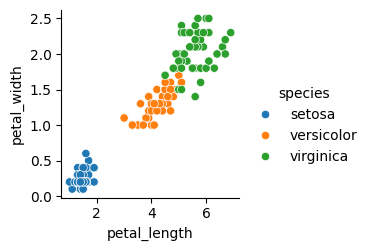

In [153]:
from pandas.io.formats import style
sns.pairplot(x_vars='petal_length', y_vars='petal_width', data=iris, hue='species')

### Paso 3: Separo mi base en atributos (variables independientes, si quieren verlo así) y etiquetas (variable dependiente)

In [154]:
features = iris.drop('species', axis=1)
target = iris['species']

In [155]:
features

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


#¿Knearest ?

![knearest](https://miro.medium.com/max/1022/1*AuXDgGrr0wbCoF6KDXXSZQ.jpeg)


El algoritmo k-nearest neighbors (KNN) es un algoritmo de aprendizaje automático simple y supervisado que puede utilizarse para resolver tanto problemas de clasificación como de regresión. Es fácil de implementar y entender, pero tiene el gran inconveniente de volverse significativamente lento a medida que crece el tamaño de los datos en uso.
KNN funciona encontrando las distancias entre una consulta y todos los ejemplos de los datos, seleccionando el número especificado de ejemplos (K) más cercanos a la consulta, y luego vota por la etiqueta más frecuente (en el caso de la clasificación) o promedia las etiquetas (en el caso de la regresión).
En el caso de la clasificación y la regresión, la elección de la K correcta para nuestros datos se realiza probando varias K y eligiendo la que mejor funciona.


En la clasificación k-NN, el resultado es la pertenencia a una clase. Un objeto se clasifica mediante un voto plural de sus vecinos, asignando el objeto a la clase más común entre sus k vecinos más cercanos (k es un número entero positivo, normalmente pequeño). Si k = 1, el objeto se asigna simplemente a la clase de ese único vecino más cercano.

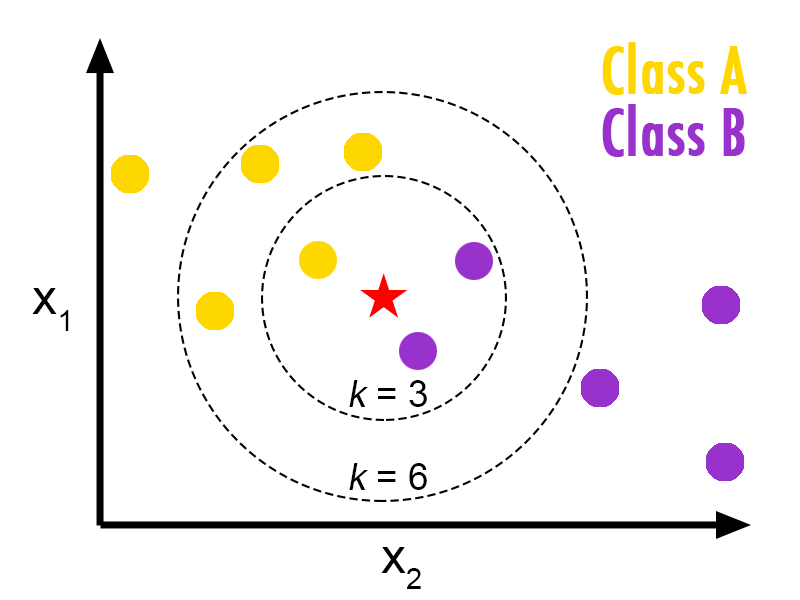

![tomato](https://jiayiwangjw.github.io/img/KNN/tomato.png)

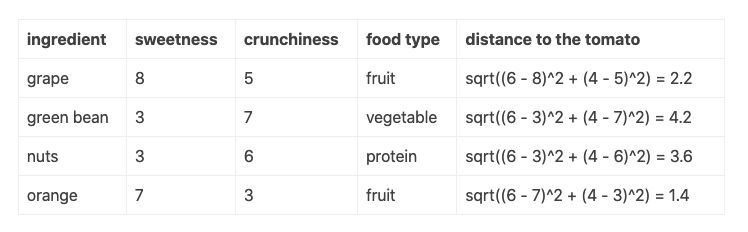

### Paso 4: Vamos a dividir nuestra base en una base de entrenamiento y otra de prueba. Dejemos 80% para que el KNN memorice, y 20% para ver qué tan bien "aprendió" a clasificar

In [156]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, stratify=target)

In [157]:
x_train

,sepal_length,sepal_width,petal_length,petal_width
46,5.1,3.8,1.6,0.2
56,6.3,3.3,4.7,1.6
26,5.0,3.4,1.6,0.4
93,5.0,2.3,3.3,1.0
129,7.2,3.0,5.8,1.6
...,...,...,...,...
48,5.3,3.7,1.5,0.2
73,6.1,2.8,4.7,1.2
38,4.4,3.0,1.3,0.2
34,4.9,3.1,1.5,0.1


En teoría, una buena K para empezar a explorar es la raíz cuadrada del número de observaciones de mi base de entrenamiento. En este caso es la raíz de 120, es decir, 11 aproximadamente.

In [158]:
len(x_train)

import math
math.sqrt(len(x_train))

10.954451150103322

![good_k](https://jiayiwangjw.github.io/img/KNN/how%20much%20is%20K.png)

### Paso 5: Normalizo mis datos para que tengan una escala común

Primero importo la función que me permite normalizar facilmente, y luego le digo que calcule media y desviación que va a usar luego para normalizar (en la parte del fit).

In [159]:
x_train

,sepal_length,sepal_width,petal_length,petal_width
46,5.1,3.8,1.6,0.2
56,6.3,3.3,4.7,1.6
26,5.0,3.4,1.6,0.4
93,5.0,2.3,3.3,1.0
129,7.2,3.0,5.8,1.6
...,...,...,...,...
48,5.3,3.7,1.5,0.2
73,6.1,2.8,4.7,1.2
38,4.4,3.0,1.3,0.2
34,4.9,3.1,1.5,0.1


In [160]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(x_train)

MinMaxScaler()

Ahora sí, re-escalo mis variables

In [161]:
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [162]:
x_train_scaled

array([[0.2       , 0.75      , 0.10169492, 0.04166667],
       [0.54285714, 0.54166667, 0.62711864, 0.625     ],
       [0.17142857, 0.58333333, 0.10169492, 0.125     ],
       [0.17142857, 0.125     , 0.38983051, 0.375     ],
       [0.8       , 0.41666667, 0.81355932, 0.625     ],
       [0.28571429, 0.41666667, 0.59322034, 0.58333333],
       [0.31428571, 0.25      , 0.57627119, 0.45833333],
       [0.6       , 0.41666667, 0.81355932, 0.875     ],
       [0.4       , 0.33333333, 0.69491525, 0.95833333],
       [0.31428571, 0.16666667, 0.45762712, 0.375     ],
       [0.57142857, 0.375     , 0.55932203, 0.5       ],
       [0.08571429, 0.5       , 0.05084746, 0.04166667],
       [0.14285714, 0.41666667, 0.06779661, 0.04166667],
       [0.57142857, 0.5       , 0.72881356, 0.91666667],
       [0.14285714, 0.45833333, 0.08474576, 0.        ],
       [0.17142857, 0.41666667, 0.10169492, 0.04166667],
       [0.37142857, 0.33333333, 0.59322034, 0.5       ],
       [0.54285714, 0.58333333,

In [163]:
y_train

,species
46,setosa
56,versicolor
26,setosa
93,versicolor
129,virginica
...,...
48,setosa
73,versicolor
38,setosa
34,setosa


In [164]:
x_train.min(), x_train.max()

(sepal_length    4.4
 sepal_width     2.0
 petal_length    1.0
 petal_width     0.1
 dtype: float64,
 sepal_length    7.9
 sepal_width     4.4
 petal_length    6.9
 petal_width     2.5
 dtype: float64)

### Paso 6: Importo mi clasificador y le digo que memorice los datos de entrenamiento

In [165]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=11)
knn.fit(x_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=11)

### Paso 7: Hago la predicción con mis atributos del set de prueba

In [166]:
x_test_scaled
y_test

,species
54,versicolor
41,setosa
134,virginica
49,setosa
53,versicolor
11,setosa
70,versicolor
76,versicolor
145,virginica
32,setosa


In [167]:
y_predict = knn.predict(x_test_scaled)

In [168]:
y_predict

array(['versicolor', 'setosa', 'virginica', 'setosa', 'versicolor',
       'setosa', 'versicolor', 'versicolor', 'virginica', 'setosa',
       'setosa', 'virginica', 'versicolor', 'virginica', 'versicolor',
       'setosa', 'virginica', 'setosa', 'setosa', 'virginica',
       'versicolor', 'versicolor', 'virginica', 'virginica', 'versicolor',
       'versicolor', 'virginica', 'setosa', 'virginica', 'setosa'],
      dtype=object)

In [169]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_predict)

0.9333333333333333

### Paso 8: revisamos qué tan bien lo hicimos

In [170]:
knn.predict([[7.1, 3.3, 5.2, 4]])

array(['virginica'], dtype=object)

**EXTRA: podemos ver con nuestro set de prueba el número de errores promedio que tendríamos con distintas K's

In [171]:
error = []

for i in range(1, 50):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(x_train, y_train)
    pred_i = knn.predict(x_test)
    error.append(np.mean(pred_i != y_test))

error

[np.float64(0.1),
 np.float64(0.13333333333333333),
 np.float64(0.1),
 np.float64(0.06666666666666667),
 np.float64(0.06666666666666667),
 np.float64(0.03333333333333333),
 np.float64(0.06666666666666667),
 np.float64(0.06666666666666667),
 np.float64(0.06666666666666667),
 np.float64(0.06666666666666667),
 np.float64(0.06666666666666667),
 np.float64(0.03333333333333333),
 np.float64(0.06666666666666667),
 np.float64(0.03333333333333333),
 np.float64(0.03333333333333333),
 np.float64(0.03333333333333333),
 np.float64(0.06666666666666667),
 np.float64(0.03333333333333333),
 np.float64(0.06666666666666667),
 np.float64(0.06666666666666667),
 np.float64(0.06666666666666667),
 np.float64(0.1),
 np.float64(0.1),
 np.float64(0.1),
 np.float64(0.1),
 np.float64(0.1),
 np.float64(0.1),
 np.float64(0.1),
 np.float64(0.1),
 np.float64(0.1),
 np.float64(0.1),
 np.float64(0.06666666666666667),
 np.float64(0.06666666666666667),
 np.float64(0.06666666666666667),
 np.float64(0.06666666666666667),
 n

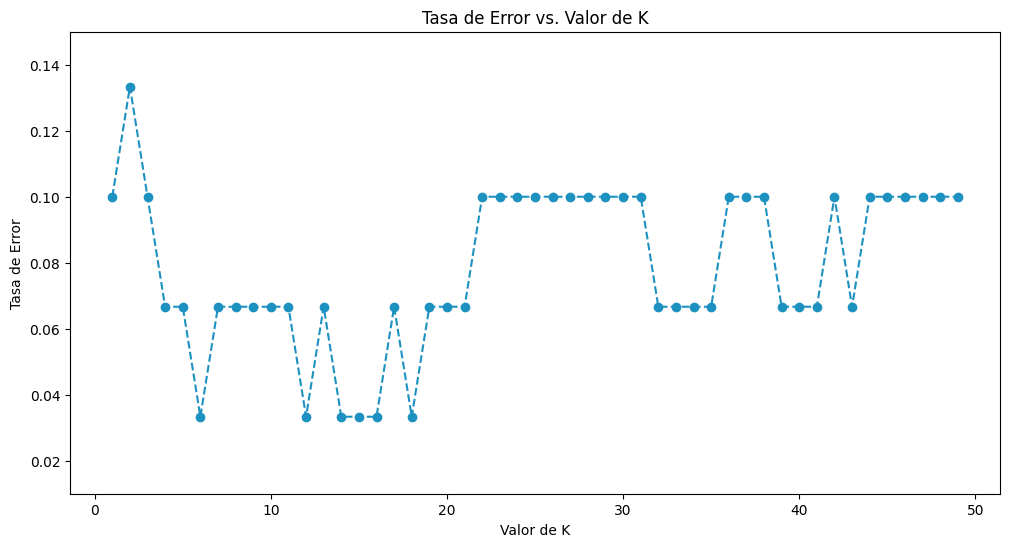

In [172]:
plt.figure(figsize = (12, 6))
plt.plot(range(1, 50), error, color = '#1d91c0', linestyle = 'dashed', marker = 'o')
plt.ylim(0.01, 0.15)
plt.xlabel('Valor de K')
plt.ylabel('Tasa de Error')
plt.title('Tasa de Error vs. Valor de K')
plt.show()

# Challenge: Cancer data

## Objetivo:
Detectar los tumores malignos y beningnos mediante el dataset que recaba múltiples características

1. Aplicar el algoritmo de KNN a ([data.csv](https://drive.google.com/file/d/18f1srPV-Bwp_JH_t4_eujW1MgY1H3rZv/view?usp=drive_link))
2. Evaluar el rendimiento del modelo

In [173]:
import numpy as np

import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

In [174]:
from google.colab import drive
drive.mount('/content/drive/')



Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [175]:
url = '/content/drive/MyDrive/AnalisisDatos/Assets/data.csv'
df_cancer = pd.read_csv(url)
df_cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [176]:
df_cancer.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [177]:
df_cancer.head(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,NaN
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,NaN
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,NaN
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,NaN


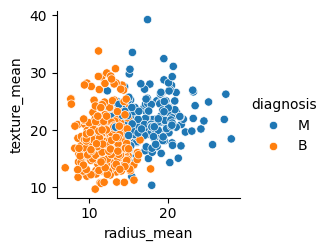

In [178]:
sns.pairplot(x_vars="radius_mean", y_vars="texture_mean", data=df_cancer, hue="diagnosis")

In [179]:
# Borrar columna unnamed 32
df_cancer.drop('Unnamed: 32', axis=1, inplace=True)
df_cancer.drop([
    'id',
    'perimeter_mean',
    'area_mean',
    'compactness_mean',
    'concave points_mean',
    'perimeter_se',
    'area_se',
    'compactness_se',
    'concave points_se',
    'perimeter_worst',
    'area_worst',
    'compactness_worst',
    'concave points_worst',
    'symmetry_worst',
    'fractal_dimension_worst',
    'smoothness_mean',
    'concavity_mean',
    'symmetry_mean',
    'fractal_dimension_mean',
    'smoothness_se',
    'concavity_se',
    'symmetry_se',
    'fractal_dimension_se',
    'smoothness_worst',
    'concavity_worst'
    ], axis = 1, inplace=True)

features = df_cancer.drop('diagnosis', axis=1).values
target = df_cancer['diagnosis'].values

In [180]:
df_cancer.head(10)

,diagnosis,radius_mean,texture_mean,radius_se,texture_se,radius_worst,texture_worst
0,M,17.99,10.38,1.0950,0.9053,25.38,17.33
1,M,20.57,17.77,0.5435,0.7339,24.99,23.41
2,M,19.69,21.25,0.7456,0.7869,23.57,25.53
3,M,11.42,20.38,0.4956,1.1560,14.91,26.50
4,M,20.29,14.34,0.7572,0.7813,22.54,16.67
5,M,12.45,15.70,0.3345,0.8902,15.47,23.75
6,M,18.25,19.98,0.4467,0.7732,22.88,27.66
7,M,13.71,20.83,0.5835,1.3770,17.06,28.14
8,M,13.00,21.82,0.3063,1.0020,15.49,30.73
9,M,12.46,24.04,0.2976,1.5990,15.09,40.68


In [181]:
df_cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   diagnosis      569 non-null    object 
 1   radius_mean    569 non-null    float64
 2   texture_mean   569 non-null    float64
 3   radius_se      569 non-null    float64
 4   texture_se     569 non-null    float64
 5   radius_worst   569 non-null    float64
 6   texture_worst  569 non-null    float64
dtypes: float64(6), object(1)
memory usage: 31.2+ KB


In [182]:
target

array(['M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M',
       'M', 'M', 'M', 'M', 'M', 'M', 'B', 'B', 'B', 'M', 'M', 'M', 'M',
       'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'B', 'M',
       'M', 'M', 'M', 'M', 'M', 'M', 'M', 'B', 'M', 'B', 'B', 'B', 'B',
       'B', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'M',
       'M', 'B', 'B', 'B', 'B', 'M', 'B', 'M', 'M', 'B', 'M', 'B', 'M',
       'M', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'M', 'M', 'B', 'B', 'B',
       'M', 'B', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'M', 'B', 'B', 'B',
       'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'M', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'M', 'B', 'M',
       'B', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'M', 'B', 'B', 'M', 'B',
       'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'M', 'B', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'B', 'B', 'M', 'M',
       'B', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'M

In [183]:
from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, stratify=target)

In [184]:
y_test

array(['B', 'B', 'B', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'B',
       'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'M', 'M', 'M', 'M',
       'B', 'B', 'M', 'M', 'B', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'M',
       'B', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'M', 'B', 'B', 'B', 'B',
       'B', 'M', 'B', 'B', 'M', 'M', 'M', 'M', 'B', 'B', 'B', 'M', 'B',
       'B', 'M', 'B', 'B', 'B', 'M', 'B', 'M', 'B', 'B', 'M', 'B', 'B',
       'B', 'M', 'B', 'B', 'M', 'M', 'B', 'M', 'B', 'B', 'B', 'M', 'B',
       'M', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'M',
       'B', 'M', 'B', 'M', 'B', 'M', 'M', 'B', 'M', 'M'], dtype=object)

In [185]:
print(f"Raíz x_train: {len(x_train)}")

import math
squared_k = math.sqrt(len(x_train))
print(f"K: {squared_k}")

Raíz x_train: 455
K: 21.330729007701542


In [186]:
x_train

array([[14.76  , 14.74  ,  0.3428,  0.3981, 17.27  , 17.93  ],
       [12.18  , 17.84  ,  0.3661,  1.511 , 12.83  , 20.92  ],
       [17.01  , 20.26  ,  0.5858,  0.8554, 19.8   , 25.05  ],
       ...,
       [11.6   , 12.84  ,  0.2315,  0.5391, 13.06  , 17.16  ],
       [ 9.567 , 15.91  ,  0.2152,  0.8301, 10.51  , 19.16  ],
       [16.27  , 20.71  ,  0.4375,  1.232 , 19.28  , 30.38  ]])

In [187]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(x_train)

MinMaxScaler()

In [188]:
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [189]:
x_train_scaled

array([[0.36816697, 0.20871369, 0.08375883, 0.00837606, 0.37063492,
        0.16818441],
       [0.24605992, 0.3373444 , 0.09219627, 0.25433168, 0.19444444,
        0.25327262],
       [0.47465569, 0.43775934, 0.17175448, 0.1094413 , 0.47103175,
        0.3708025 ],
       ...,
       [0.21860949, 0.12987552, 0.04345464, 0.03953766, 0.20357143,
        0.14627205],
       [0.12239103, 0.25726141, 0.03755206, 0.10384989, 0.10238095,
        0.20318725],
       [0.43963273, 0.45643154, 0.11805178, 0.1926715 , 0.45039683,
        0.5224815 ]])

In [190]:
y_train

array(['B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'M',
       'M', 'M', 'B', 'M', 'B', 'M', 'B', 'B', 'B', 'B', 'M', 'M', 'B',
       'M', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'B',
       'B', 'B', 'B', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'M', 'M', 'B',
       'M', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'M', 'B', 'M', 'B',
       'M', 'B', 'B', 'M', 'B', 'M', 'M', 'M', 'B', 'B', 'M', 'B', 'B',
       'B', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'B',
       'M', 'B', 'B', 'M', 'M', 'M', 'B', 'M', 'B', 'B', 'M', 'M', 'B',
       'B', 'M', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'M', 'B', 'M', 'M',
       'B', 'B', 'M', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'M', 'B',
       'M', 'B', 'B', 'M', 'B', 'B', 'M', 'M', 'B', 'B', 'M', 'M', 'M',
       'B', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'B',
       'B', 'B', 'B', 'B', 'B', 'M', 'B', 'M', 'M', 'B', 'M', 'B', 'M',
       'M', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B

In [191]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=11)

knn.fit(x_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=11)

In [192]:
x_test_scaled
y_test

array(['B', 'B', 'B', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'B',
       'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'M', 'M', 'M', 'M',
       'B', 'B', 'M', 'M', 'B', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'M',
       'B', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'M', 'B', 'B', 'B', 'B',
       'B', 'M', 'B', 'B', 'M', 'M', 'M', 'M', 'B', 'B', 'B', 'M', 'B',
       'B', 'M', 'B', 'B', 'B', 'M', 'B', 'M', 'B', 'B', 'M', 'B', 'B',
       'B', 'M', 'B', 'B', 'M', 'M', 'B', 'M', 'B', 'B', 'B', 'M', 'B',
       'M', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'M',
       'B', 'M', 'B', 'M', 'B', 'M', 'M', 'B', 'M', 'M'], dtype=object)

In [193]:
y_pred = knn.predict(x_test_scaled)

In [194]:
y_pred

array(['B', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'M', 'M', 'M', 'M',
       'B', 'B', 'M', 'M', 'B', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'M',
       'B', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'M', 'M', 'B', 'B', 'B',
       'B', 'M', 'B', 'B', 'M', 'M', 'B', 'M', 'B', 'B', 'B', 'M', 'B',
       'B', 'M', 'B', 'B', 'B', 'M', 'B', 'M', 'B', 'B', 'M', 'B', 'B',
       'B', 'M', 'M', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'B',
       'M', 'B', 'M', 'B', 'B', 'M', 'B', 'M', 'B', 'B', 'B', 'B', 'M',
       'B', 'B', 'B', 'M', 'B', 'M', 'M', 'B', 'M', 'M'], dtype=object)

In [195]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.9298245614035088

In [196]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           B       0.93      0.96      0.95        72
           M       0.93      0.88      0.90        42

    accuracy                           0.93       114
   macro avg       0.93      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [197]:
sample_input = [[13.540, 	14.36, 	0.2699, 	0.7886, 	15.110, 	19.26]]
scaled_input = scaler.transform(sample_input)
knn.predict(scaled_input)

array(['B'], dtype=object)

In [198]:
error = []

for i in range(1, 50):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(x_train, y_train)
    pred_i = knn.predict(x_test)
    error.append(np.mean(pred_i != y_test))

error

[np.float64(0.07894736842105263),
 np.float64(0.07894736842105263),
 np.float64(0.09649122807017543),
 np.float64(0.08771929824561403),
 np.float64(0.09649122807017543),
 np.float64(0.08771929824561403),
 np.float64(0.09649122807017543),
 np.float64(0.07894736842105263),
 np.float64(0.07894736842105263),
 np.float64(0.07894736842105263),
 np.float64(0.06140350877192982),
 np.float64(0.06140350877192982),
 np.float64(0.07017543859649122),
 np.float64(0.05263157894736842),
 np.float64(0.07017543859649122),
 np.float64(0.06140350877192982),
 np.float64(0.07017543859649122),
 np.float64(0.06140350877192982),
 np.float64(0.07017543859649122),
 np.float64(0.07017543859649122),
 np.float64(0.07017543859649122),
 np.float64(0.07017543859649122),
 np.float64(0.07017543859649122),
 np.float64(0.07017543859649122),
 np.float64(0.06140350877192982),
 np.float64(0.07017543859649122),
 np.float64(0.07017543859649122),
 np.float64(0.07894736842105263),
 np.float64(0.07894736842105263),
 np.float64(0.

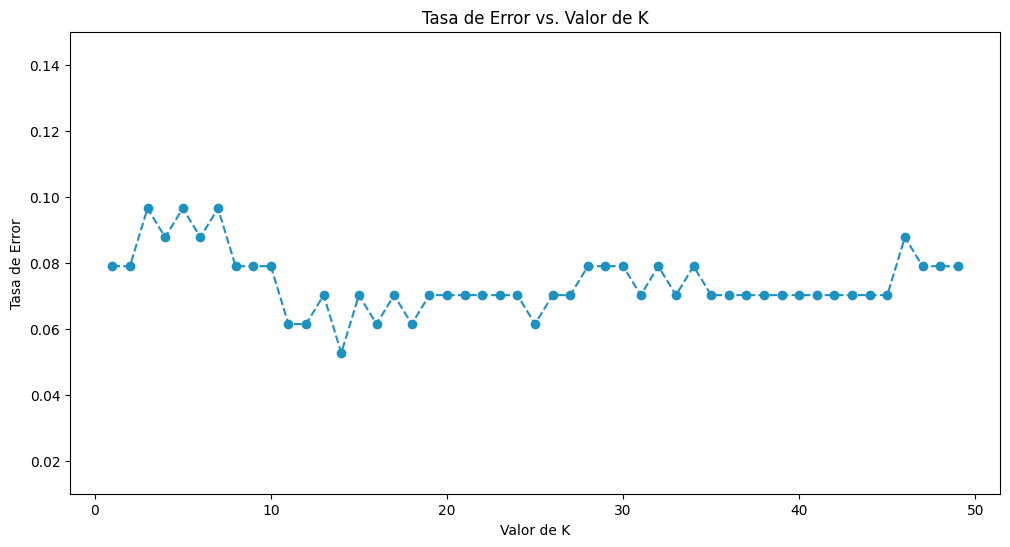

In [199]:
plt.figure(figsize = (12, 6))
plt.plot(range(1, 50), error, color = '#1d91c0', linestyle = 'dashed', marker = 'o')
plt.ylim(0.01, 0.15)
plt.xlabel('Valor de K')
plt.ylabel('Tasa de Error')
plt.title('Tasa de Error vs. Valor de K')
plt.show()

# Challenge: Wine Quality data

## Objetivo:
Determinar la calidad del vino con base en su características

1. Aplicar el algoritmo de KNN a Wine Quality Data que se encuentra dentro del siguiente link 👇🏼

> https://archive.ics.uci.edu/ml/datasets/Wine+Quality

2. Evaluar el rendimiento del modelo

In [200]:
!pip install ucimlrepo

In [201]:
import numpy as np

import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

In [202]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

In [203]:
# data (as pandas dataframes)
X = wine_quality.data.features
y = wine_quality.data.targets

print(wine_quality.metadata)
print(wine_quality.variables)

{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [204]:
y['quality'].unique()

array([5, 6, 7, 4, 8, 3, 9])

In [205]:
X.head(10)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5


In [206]:
y.head(10)

,quality
0,5
1,5
2,5
3,6
4,5
5,5
6,5
7,7
8,7
9,5


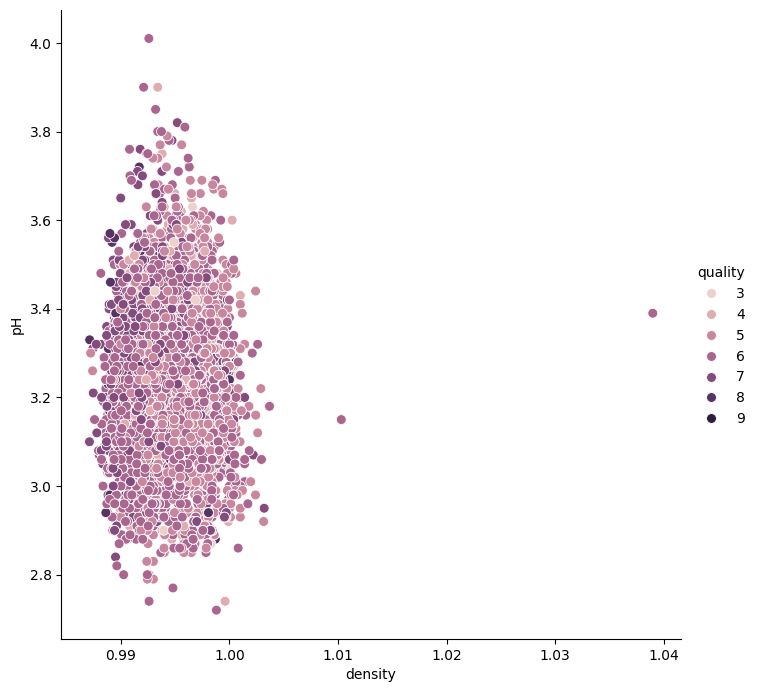

In [207]:
df_wine_quality = pd.concat([X, y], axis=1)
sns.pairplot(x_vars='density', y_vars='pH', data=df_wine_quality, plot_kws={'s': 50}, height=7, hue='quality')

In [208]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [209]:
# Conjunto de entrenamiento
len(x_train)

5197

In [210]:
# Conjunto de pruebas
len(x_test)

1300

In [211]:
import math
math.sqrt(len(x_train))

72.09022125087424

In [212]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(x_train) # Construimos las equivalencias

MinMaxScaler()

In [213]:
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)
x_test

array([[0.32231405, 0.33333333, 0.00813008, ..., 0.46511628, 0.18644068,
        0.36231884],
       [0.1322314 , 0.34333333, 0.08130081, ..., 0.49612403, 0.08474576,
        0.1884058 ],
       [0.2892562 , 0.09333333, 0.39837398, ..., 0.2248062 , 0.02824859,
        0.46376812],
       ...,
       [0.23966942, 0.11333333, 0.21138211, ..., 0.51937984, 0.1299435 ,
        0.27536232],
       [0.26446281, 0.12666667, 0.3902439 , ..., 0.37209302, 0.15254237,
        0.20289855],
       [0.09917355, 0.16666667, 0.18699187, ..., 0.53488372, 0.23163842,
        0.55072464]])

In [214]:
x_train.min(), x_train.max()

(np.float64(0.0), np.float64(1.0000000000000002))

In [215]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=1)
classifier.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=1)

In [216]:
y_pred = classifier.predict(x_test)
y_pred

array([7, 5, 7, ..., 7, 6, 7])

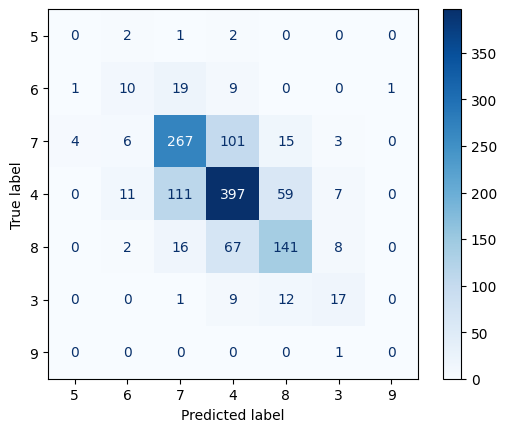

In [217]:
from sklearn.metrics import ConfusionMatrixDisplay
class_names = [5, 6, 7, 4, 8, 3, 9]
normalize = None
ConfusionMatrixDisplay.from_estimator(
        classifier,
        x_test,
        y_test.values,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )

In [218]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.64

In [219]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         5
           4       0.32      0.25      0.28        40
           5       0.64      0.67      0.66       396
           6       0.68      0.68      0.68       585
           7       0.62      0.60      0.61       234
           8       0.47      0.44      0.45        39
           9       0.00      0.00      0.00         1

    accuracy                           0.64      1300
   macro avg       0.39      0.38      0.38      1300
weighted avg       0.64      0.64      0.64      1300



In [220]:
sample_input = [[7.3, 	0.65, 	0.00, 	1.2, 	0.065, 	15.0, 	21.0, 	0.9946, 	3.39, 	0.47, 	10.0]]
scaled_input = scaler.transform(sample_input)
classifier.predict(scaled_input)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([7])

In [221]:
error = []

for i in range(1, 50):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(x_train, y_train.values.ravel())
    pred_i = knn.predict(x_test)
    error.append(np.mean(pred_i != y_test.values.ravel()))

error

[np.float64(0.36),
 np.float64(0.4276923076923077),
 np.float64(0.4492307692307692),
 np.float64(0.4369230769230769),
 np.float64(0.4276923076923077),
 np.float64(0.43923076923076926),
 np.float64(0.43153846153846154),
 np.float64(0.4269230769230769),
 np.float64(0.42846153846153845),
 np.float64(0.42230769230769233),
 np.float64(0.4307692307692308),
 np.float64(0.43),
 np.float64(0.43923076923076926),
 np.float64(0.4461538461538462),
 np.float64(0.44384615384615383),
 np.float64(0.44461538461538463),
 np.float64(0.44384615384615383),
 np.float64(0.43846153846153846),
 np.float64(0.43153846153846154),
 np.float64(0.43153846153846154),
 np.float64(0.43923076923076926),
 np.float64(0.44461538461538463),
 np.float64(0.44),
 np.float64(0.44076923076923075),
 np.float64(0.4430769230769231),
 np.float64(0.44384615384615383),
 np.float64(0.4453846153846154),
 np.float64(0.44076923076923075),
 np.float64(0.44461538461538463),
 np.float64(0.44846153846153847),
 np.float64(0.4492307692307692),
 

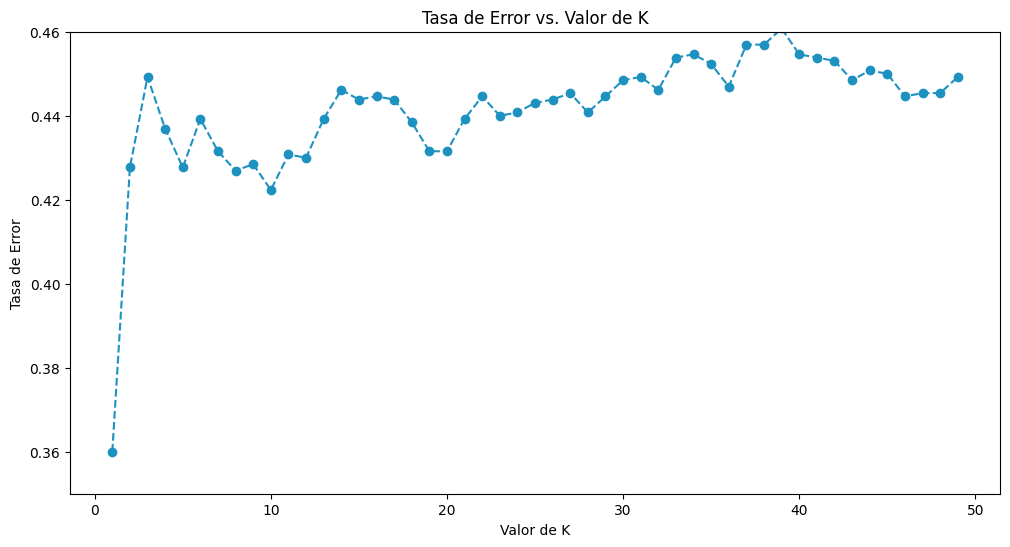

In [222]:
plt.figure(figsize = (12, 6))
plt.plot(range(1, 50), error, color = '#1d91c0', linestyle = 'dashed', marker = 'o')
plt.ylim(0.35, 0.46)
plt.xlabel('Valor de K')
plt.ylabel('Tasa de Error')
plt.title('Tasa de Error vs. Valor de K')
plt.show() # Display the plot